In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/train (1).csv
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/test (1).csv


In [2]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load Data

data_path = '/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques'

# Load datasets
train = pd.read_csv(f'{data_path}/train (1).csv')
test = pd.read_csv(f'{data_path}/test (1).csv')
sample = pd.read_csv(f'{data_path}/sample_submission.csv')

# Display shapes
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
print("Sample Shape:", sample.shape)

# Preview
train.head()


Train Shape: (1460, 81)
Test Shape : (1459, 80)
Sample Shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Missing Values ---
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


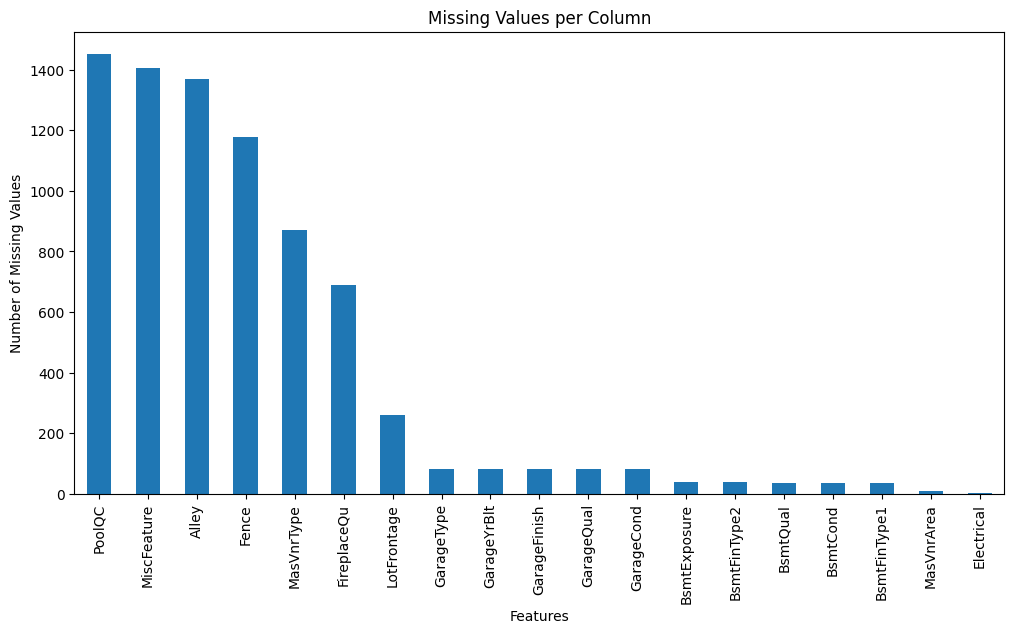


--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Outliers removed.
Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_train.csv


/tmp/ipykernel_16/3037516151.py:44: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.000000,0.4,RL,0.443038,0.400706,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.090909,0.50,WD,Normal,0.586254
2,0.001375,0.4,RL,0.481013,0.602391,Pave,IR1,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.727273,0.50,WD,Normal,0.637801
4,0.002749,0.4,RL,0.683544,0.819203,Pave,IR1,Lvl,AllPub,FR2,...,0.0,0.0,0.0,0.0,0.0,1.000000,0.50,WD,Normal,0.728866
6,0.004124,0.0,RL,0.569620,0.518404,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.636364,0.25,WD,Normal,0.924742
10,0.006873,0.0,RL,0.506329,0.598790,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.090909,0.50,WD,Normal,0.314777


In [4]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    # Filter columns with missing values
    missing = missing[missing > 0].sort_values(ascending=False)

    # Plot bar chart
    plt.figure(figsize=(12,6))
    missing.plot(kind='bar')

    plt.title('Missing Values per Column')
    plt.xlabel('Features')
    plt.ylabel('Number of Missing Values')

    plt.show()

    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    print("Outliers removed.")
    return df


# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    df = remove_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(train, '/kaggle/working/cleaned_data_train.csv')

# Preview
cleaned_df.head()

In [5]:
# Count missing values
missing = cleaned_df.isnull().sum().sum()
print(missing)

0
